# Лабораторная работа №6
## Жадная стратегия и динамическое программирование
## Ревенко Данила, ФИТ-231
### № 1
Предположим, что вы собираетесь в турпоход. У вас есть рюкзак, емкость которого
составляет 6 фунтов, и список предметов, которые вы можете положить с собой в рюкзак.
У каждого предмета есть вес и ценность. Чем выше ценность, тем важнее для вас предмет.
Нарисуйте и вручную заполните таблицу, которая даст оптимальный набор предметов для
похода и общую ценность получившегося рюкзака. Ориентируйтесь на алгоритм
динамического программирования, описанный в лекции.
Список предметов возьмите согласно вашему варианту.

Вариант 5.

1. вода, 1 фунт, 8;

2. книга, 1 фунт, 8;

3. еда, 3 фунта, 9;

4. куртка, 2 фунта, 5;

5. камера, 2 фунта, 6

| Предмет (вес/ценность) | 1 | 2  | 3   | 4  | 5  | 6  |
|------------------------|---|----|-----|----|----|----|
| Вода (1,8)             | 8 | 8  | 8   | 8  | 8  | 8  |
| Книга (1,8)            | 8 | 16 | 16  | 16 | 16 | 16 |
| Еда (3,9)              | 8 | 16 | 16  | 17 | 25 | 25 |
| Куртка (2,5)           | 8 | 16 | 16  | 21 | 25 | 27 |
| Камера 2,6)            | 8 | 16 | 16  | 22 | 27 | 27 |


### № 2
Напишите программу, которая моделирует задачу о рюкзаке. Пользователь вводит объем
рюкзака и список предметов с указанием их веса и ценности. Вам необходимо подобрать
набор предметов максимальной ценности, которые поместятся в рюкзаке. Реализуйте три
варианта решения этой задачи:
1. Полный перебор
2. Жадный алгоритм
3. Динамическое программирование
Укажите вычислительная сложность (в O-нотации) для каждого алгоритма. Постройте
графики возрастания времени выполнения алгоритмов при увеличении входных данных.
Приведите примеры входных данных, когда жадный алгоритм дает оптимальное решение
и когда дает неоптимальное решение.


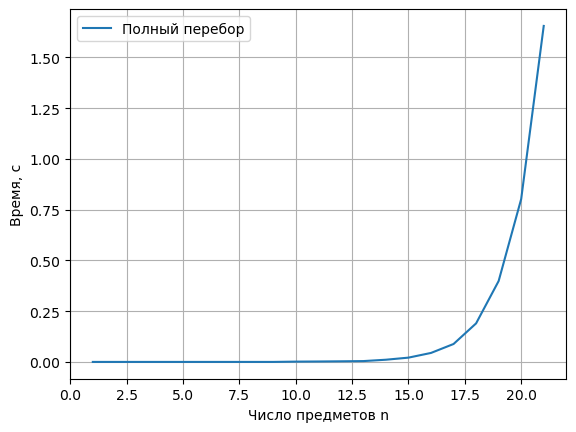

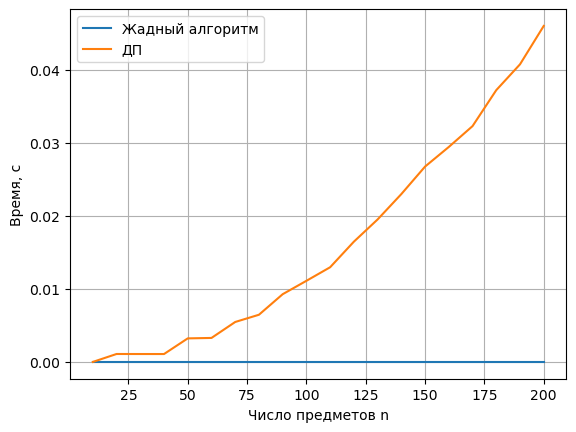


Пример 1: жадный алгоритм ДАЁТ оптимальное решение
Входные данные:
Вместимость: 6
Предметы: [('A', 2, 8), ('B', 3, 9), ('C', 1, 2)]
Полный перебор: ценность = 19 , набор = [('A', 2, 8), ('B', 3, 9), ('C', 1, 2)]
Жадный алгоритм: ценность = 19 , набор = [('A', 2, 8), ('B', 3, 9), ('C', 1, 2)]

Пример 2: жадный алгоритм НЕ ДАЁТ оптимальное решение
Входные данные:
Вместимость: 6
Предметы: [('X', 5, 10), ('Y', 3, 9), ('Z', 3, 9)]
Полный перебор (оптимум): ценность = 18 , набор = [('Y', 3, 9), ('Z', 3, 9)]
Жадный по максимальной ценности: ценность = 10 , набор = [('X', 5, 10)]
Комментарий: жадный выбирает только X (вес 5, ценность 10),
а оптимально взять Y и Z (вес 3+3=6, ценность 9+9=18).


In [23]:
from itertools import combinations

def knapsack_bruteforce(items, capacity):
    n = len(items)
    best_value = 0
    best_set = []

    # перебираем все размеры подмножеств
    for r in range(n + 1):
        for subset in combinations(range(n), r):
            total_weight = 0
            total_value = 0
            chosen = []
            for i in subset:
                name, w, v = items[i]
                total_weight += w
                total_value += v
                chosen.append(items[i])
            if total_weight <= capacity and total_value > best_value:
                best_value = total_value
                best_set = chosen

    return best_value, best_set

def knapsack_greedy(items, capacity):
    # сортируем по убыванию v/w
    items_sorted = sorted(items, key=lambda x: x[2] / x[1], reverse=True)

    total_weight = 0
    total_value = 0
    chosen = []

    for name, w, v in items_sorted:
        if total_weight + w <= capacity:
            chosen.append((name, w, v))
            total_weight += w
            total_value += v

    return total_value, chosen

def knapsack_dp(items, capacity):
    n = len(items)
    # таблица (n+1) x (capacity+1)
    dp = [[0] * (capacity + 1) for _ in range(n + 1)]

    # заполняем таблицу
    for i in range(1, n + 1):
        name, w, v = items[i - 1]
        for cap in range(1, capacity + 1):
            # не берем предмет i
            dp[i][cap] = dp[i - 1][cap]
            # пытаемся взять предмет i
            if w <= cap:
                dp[i][cap] = max(dp[i][cap], v + dp[i - 1][cap - w])

    # восстановление выбранных предметов
    chosen = []
    cap = capacity
    i = n
    while i > 0 and cap > 0:
        if dp[i][cap] != dp[i - 1][cap]:
            # предмет i взяли
            name, w, v = items[i - 1]
            chosen.append(items[i - 1])
            cap -= w
        i -= 1

    chosen.reverse()
    return dp[n][capacity], chosen, dp

import random
import time
import matplotlib.pyplot as plt

def generate_items(n, max_weight=10, max_value=20):
    items = []
    for i in range(n):
        w = random.randint(1, max_weight)
        v = random.randint(1, max_value)
        items.append((f"item{i}", w, v))
    return items

def measure(func, n_values, capacity_factor=5):
    times = []
    for n in n_values:
        items = generate_items(n)
        capacity = capacity_factor * n
        start = time.time()
        func(items, capacity)
        end = time.time()
        times.append(end - start)
    return times

n_values_small = list(range(1, 22))   # для перебора очень маленькие n
n_values_big   = list(range(10, 210, 10))  # для жадного и ДП

# замер для полного перебора
bf_times = measure(knapsack_bruteforce, n_values_small)

# жадный и ДП
greedy_times = measure(knapsack_greedy, n_values_big)
dp_times = measure(lambda items, cap: knapsack_dp(items, cap)[0:2], n_values_big)

# графики
plt.figure()
plt.plot(n_values_small, bf_times, label="Полный перебор")
plt.xlabel("Число предметов n")
plt.ylabel("Время, с")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(n_values_big, greedy_times, label="Жадный алгоритм")
plt.plot(n_values_big, dp_times, label="ДП")
plt.xlabel("Число предметов n")
plt.ylabel("Время, с")
plt.legend()
plt.grid(True)
plt.show()

# Жадный алгоритм оптимален / не оптимален

print("\nПример 1: жадный алгоритм ДАЁТ оптимальное решение")
capacity_opt = 6
items_opt = [
    ("A", 2, 8),
    ("B", 3, 9),
    ("C", 1, 2),
]
bf_val_opt, bf_set_opt = knapsack_bruteforce(items_opt, capacity_opt)
gr_val_opt, gr_set_opt = knapsack_greedy(items_opt, capacity_opt)

print("Входные данные:")
print("Вместимость:", capacity_opt)
print("Предметы:", items_opt)
print("Полный перебор: ценность =", bf_val_opt, ", набор =", bf_set_opt)
print("Жадный алгоритм: ценность =", gr_val_opt, ", набор =", gr_set_opt)

print("\nПример 2: жадный алгоритм НЕ ДАЁТ оптимальное решение")
# жадный по максимальной ЦЕННОСТИ (v) ошибается
capacity_bad = 6
items_bad = [
    ("X", 5, 10),
    ("Y", 3, 9),
    ("Z", 3, 9),
]

def knapsack_greedy_by_value(items, capacity):
    # жадный по абсолютной ценности (НЕ по v/w!)
    items_sorted = sorted(items, key=lambda x: x[2], reverse=True)
    total_weight = 0
    total_value = 0
    chosen = []
    for name, w, v in items_sorted:
        if total_weight + w <= capacity:
            chosen.append((name, w, v))
            total_weight += w
            total_value += v
    return total_value, chosen

bf_val_bad, bf_set_bad = knapsack_bruteforce(items_bad, capacity_bad)
gr_val_bad, gr_set_bad = knapsack_greedy_by_value(items_bad, capacity_bad)

print("Входные данные:")
print("Вместимость:", capacity_bad)
print("Предметы:", items_bad)
print("Полный перебор (оптимум): ценность =", bf_val_bad, ", набор =", bf_set_bad)
print("Жадный по максимальной ценности: ценность =", gr_val_bad, ", набор =", gr_set_bad)
print("Комментарий: жадный выбирает только X (вес 5, ценность 10),")
print("а оптимально взять Y и Z (вес 3+3=6, ценность 9+9=18).")

### № 3
Нарисуйте и вручную заполните таблицу для вычисления самой длинной общей подстроки
между строками blue и clue. Ориентируйтесь на алгоритм динамического
программирования, описанный в лекции.

|  | c | l | u | e |
|-----------------------|---|---|---|---|
|b                     | 0 | 0 | 0 | 0 |
|l                     | 0 | 1 | 0 | 0 |
|u                     | 0 | 0 | 2 | 0 |
|e                     | 0 | 0 | 0 | 3 |

### №4
Напишите программу, реализующую алгоритм нахождения самой длинной общей
подстроки из лекции. Пользователь вводит слово с ошибкой и далее список похожих слов.
Ваша программа должна вывести самое похожее слово согласно данному алгоритму

In [24]:
def longest_common_substring(s1: str, s2: str) -> int:
    # Возвращает длину самой длинной общей подстроки двух строк
    n, m = len(s1), len(s2)
    dp = [[0] * (m + 1) for _ in range(n + 1)]  # dp[i][j] — длина общей подстроки, заканчивающейся в s1[i-1], s2[j-1]
    max_len = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if s1[i - 1] == s2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
                if dp[i][j] > max_len:
                    max_len = dp[i][j]
            else:
                dp[i][j] = 0
    return max_len


def most_similar_word_with_lcs(misspelled: str, candidates: list[str]) -> str:
    # Возвращает слово из списка с максимальной длиной общей подстроки с misspelled
    best_word = None
    best_score = -1

    for word in candidates:
        score = longest_common_substring(misspelled, word)
        if score > best_score:
            best_score = score
            best_word = word

    return best_word


print("Поиск самого похожего слова (алгоритм длиннейшей общей подстроки)")
misspelled = input("Введите слово с ошибкой: ").strip()

print("Введите похожие слова через пробел:")
line = input().strip()
candidates = [w for w in line.split() if w]

if not candidates:
    print("Список похожих слов пуст.")
else:
    best = most_similar_word_with_lcs(misspelled, candidates)
    print("Самое похожее слово:", best)

Поиск самого похожего слова (алгоритм длиннейшей общей подстроки)
Введите похожие слова через пробел:
Самое похожее слово: progress


### №5
Напишите программу, реализующую алгоритм нахождения самой длинной общей
подпоследовательности из лекции. Пользователь вводит слово с ошибкой и далее список
похожих слов. Ваша программа должна вывести самое похожее слово согласно данному
алгоритму

In [25]:
def longest_common_subsequence(s1: str, s2: str) -> int:
    # Возвращает длину самой длинной общей подпоследовательности двух строк
    n, m = len(s1), len(s2)
    dp = [[0] * (m + 1) for _ in range(n + 1)]  # dp[i][j] — длина LCS для s1[:i] и s2[:j]

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if s1[i - 1] == s2[j - 1]:  # Если символы совпадают, продолжаем подпоследовательность
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:  # Иначе берём максимум: пропустить символ из первой или второй строки
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[n][m]


def most_similar_word_lcs(misspelled: str, candidates: list[str]) -> str:
    # Возвращает слово из списка с максимальной длиной общей подпоследовательности с misspelled
    best_word = None  # Текущее лучшее слово
    best_score = -1  # Текущая максимальная длина LCS

    for word in candidates:
        score = longest_common_subsequence(misspelled, word)  # Длина LCS с текущим словом
        # print(word, score)  # Для отладки можно раскомментировать
        if score > best_score:  # Если текущее слово лучше, обновляем ответ
            best_score = score
            best_word = word

    return best_word


# Основной сценарий работы программы (ввод слова с ошибкой и списка похожих слов)
print("Поиск самого похожего слова (алгоритм длиннейшей общей подпоследовательности)")
misspelled = input("Введите слово с ошибкой: ").strip()

print("Введите похожие слова через пробел:")
line = input().strip()
candidates = [w for w in line.split() if w]  # Разбиваем строку на слова и убираем лишние пробелы

if not candidates:  # Если список пуст, дальше нет смысла продолжать
    print("Список похожих слов пуст.")
else:
    best = most_similar_word_lcs(misspelled, candidates)  # Ищем самое похожее слово
    print("Самое похожее слово:", best)

Поиск самого похожего слова (алгоритм длиннейшей общей подпоследовательности)
Введите похожие слова через пробел:
Самое похожее слово: program


### №6
Имеется n предметов различных размеров (от 0.1 до 1.0). Есть неограниченное количество
одинаковых ящиков вместимостью 1.0. Необходимо разложить все n предметов в
минимальное количество ящиков.
Напишите программу, реализующую 4 жадных стратегии раскладки предметов по ящикам:

1. Первый подходящий ящик. Ящики просматриваются поочередно пока не найдется
ящик, в котором достаточно свободного места для упаковки очередного предмета.
Если такого ящика нет, то предмет кладется в новый ящик.

Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5)
пройдет следующим образом: первый ящик — [0.5, 0.3, 0.1], второй — [0.7, 0.2],
третий — [0.9], четвертый — [0.6, 0.4], пятый — [0.8], шестой — [0.5]. Т.е. ответом
будет 6 ящиков.

In [26]:
BOX_CAPACITY = 1.0
EPS = 1e-9

def first_fit(items):
    # Первый подходящий ящик
    boxes = []
    for item in items:
        placed = False
        for box in boxes:
            free = BOX_CAPACITY - sum(box)
            if free + EPS >= item:
                box.append(item)
                placed = True
                break
        if not placed:
            boxes.append([item])
    return boxes

items = [0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5]
boxes_ff = first_fit(items)
print(len(boxes_ff))
print(boxes_ff)

6
[[0.5, 0.3, 0.1], [0.7, 0.2], [0.9], [0.6, 0.4], [0.8], [0.5]]


2. Наиболее подходящий ящик. Выбирается ящик, в котором останется как можно
меньше места после помещения туда очередного предмета. Укладка в новый ящик
применяется только в том случае, если очередной предмет не помещается ни в какой
из имеющихся ящиков.

Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5)
пройдет следующим образом: первый ящик — [0.5, 0.5], второй — [0.7, 0.3], третий
— [0.9, 0.1], четвертый — [0.6, 0.4], пятый — [0.8, 0.2]. Т.е. ответом будет 5 ящиков.

In [27]:
def best_fit(items):
    # Наиболее подходящий ящик (минимальный остаток места)
    boxes = []
    for item in items:
        best_index = None
        best_free_after = None
        for i, box in enumerate(boxes):
            free = BOX_CAPACITY - sum(box)
            if free + EPS >= item:
                free_after = free - item
                if free_after < 0 and abs(free_after) < EPS:
                    free_after = 0.0
                if best_index is None or free_after < best_free_after:
                    best_index = i
                    best_free_after = free_after
        if best_index is None:
            boxes.append([item])
        else:
            boxes[best_index].append(item)
    return boxes

items = [0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5]
boxes_bf = best_fit(items)
print(len(boxes_bf))
print(boxes_bf)

5
[[0.5, 0.5], [0.7, 0.3], [0.9, 0.1], [0.6, 0.4], [0.8, 0.2]]


3. Следующий подходящий ящик. Мы продолжаем укладку каждого ящика до тех пор,
пока очередной предмет в него помещается. Если предмет не влезает в ящик, то мы
берем новый ящик, а к ранее уложенным ящикам уже не возвращаемся.

Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5)
пройдет следующим образом: первый ящик — [0.5], второй — [0.7, 0.3], третий —
[0.9], четвертый — [0.6], пятый — [0.8, 0.1], шестой — [0.4, 0.2], седьмой — [0.5].
Т.е. ответом будет 7 ящиков.

In [31]:
def next_fit(items):
    # Следующий подходящий ящик
    boxes = []
    if not items:
        print(0)
        print(boxes)
    else:
        boxes.append([])
        current_index = 0
        for item in items:
            current_box = boxes[current_index]
            free = BOX_CAPACITY - sum(current_box)
            if free + EPS >= item:
                current_box.append(item)
            else:
                boxes.append([item])
                current_index += 1
        return boxes

items = [0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5]

boxes_nf = next_fit(items)
print(len(boxes_nf))
print(boxes_nf)

7
[[0.5], [0.7, 0.3], [0.9], [0.6], [0.8, 0.1], [0.4, 0.2], [0.5]]


4. Наименее подходящий ящик. Выбирается ящик, в котором останется как можно
больше места после помещения туда очередного предмета. Укладка в новый ящик
применяется только в том случае, если очередной предмет не помещается ни в какой
из имеющихся ящиков.

Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5)
пройдет следующим образом: первый ящик — [0.5, 0.3], второй — [0.7], третий —
[0.9], четвертый — [0.6, 0.1], пятый — [0.8], шестой — [0.4, 0.2], седьмой — [0.5].
Т.е. ответом будет 7 ящиков.

In [29]:
def worst_fit(items):
    # Наименее подходящий ящик (максимальный остаток места)
    boxes = []
    for item in items:
        worst_index = None
        worst_free_after = None
        for i, box in enumerate(boxes):
            free = BOX_CAPACITY - sum(box)
            if free + EPS >= item:
                free_after = free - item
                if free_after < 0 and abs(free_after) < EPS:
                    free_after = 0.0
                if worst_index is None or free_after > worst_free_after:
                    worst_index = i
                    worst_free_after = free_after
        if worst_index is None:
            boxes.append([item])
        else:
            boxes[worst_index].append(item)
    return boxes

items = [0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5]
boxes_wf = worst_fit(items)
print(len(boxes_wf))
print(boxes_wf)

7
[[0.5, 0.3], [0.7], [0.9], [0.6, 0.1], [0.8], [0.4, 0.2], [0.5]]


Сгенерируйте случайные наборы предметов (размером от 0.1 до 0.9) в количестве 50, 100,
200 и 500. Осуществите на каждом из наборов проверку всех четырех стратегий и
посмотрите, какая из них приводит к меньшему числу ящиков.

In [32]:
import random

def generate_items(n):
    # Генерирует n предметов со случайным размером от 0.1 до 0.9 (округление до 2 знаков)
    return [round(random.uniform(0.1, 0.9), 2) for _ in range(n)]

sizes = [50, 100, 200, 500]

for n in sizes:
    items = generate_items(n)

    boxes_ff = first_fit(items)
    boxes_bf = best_fit(items)
    boxes_nf = next_fit(items)
    boxes_wf = worst_fit(items)

    counts = {
        "First Fit": len(boxes_ff),
        "Best Fit": len(boxes_bf),
        "Next Fit": len(boxes_nf),
        "Worst Fit": len(boxes_wf),
    }

    min_boxes = min(counts.values())
    best_strategies = [name for name, c in counts.items() if c == min_boxes]

    print(f"\nКоличество предметов: {n}")
    print("First Fit :", counts["First Fit"])
    print("Best Fit  :", counts["Best Fit"])
    print("Next Fit  :", counts["Next Fit"])
    print("Worst Fit :", counts["Worst Fit"])
    print("Минимальное число ящиков:", min_boxes)
    print("Лучшая(ие) стратегия(и):", ", ".join(best_strategies))


Количество предметов: 50
First Fit : 28
Best Fit  : 27
Next Fit  : 34
Worst Fit : 30
Минимальное число ящиков: 27
Лучшая(ие) стратегия(и): Best Fit

Количество предметов: 100
First Fit : 66
Best Fit  : 66
Next Fit  : 76
Worst Fit : 68
Минимальное число ящиков: 66
Лучшая(ие) стратегия(и): First Fit, Best Fit

Количество предметов: 200
First Fit : 115
Best Fit  : 112
Next Fit  : 143
Worst Fit : 125
Минимальное число ящиков: 112
Лучшая(ие) стратегия(и): Best Fit

Количество предметов: 500
First Fit : 276
Best Fit  : 272
Next Fit  : 352
Worst Fit : 311
Минимальное число ящиков: 272
Лучшая(ие) стратегия(и): Best Fit


Количество предметов | First Fit | Best Fit | Next Fit | Worst Fit | Минимум ящиков | Лучшая(ие) стратегия(и)
---------------------|----------|----------|----------|-----------|----------------|-------------------------
50                   | 28       | 27       | 34       | 30        | 27             | Best Fit
100                  | 66       | 66       | 76       | 68        | 66             | First Fit, Best Fit
200                  | 115      | 112      | 143      | 125       | 112            | Best Fit
500                  | 276      | 272      | 352      | 311       | 272            | Best Fit

### №7
Есть купюры и монеты номиналами: 1, 3, 4, 10, 50, 100. В банкомате неограниченное
количество купюр и монет каждого номинала. Мы хотим снять со счета n рублей. Нужно
вывести на экран минимальный набор купюр и монет, который может выдать банкомат,
чтобы сумма получилась ровно n.
1. Напишите жадный алгоритм решения задачи. Подсказка: выбирайте купюры и
монеты по убыванию номинала.
2. Используйте динамическое программирование, чтобы рассчитать минимальное
количество требуемых купюр и монет.
3. Приведите пример входных данных, когда жадный алгоритм выдает не оптимальное
решение.


In [33]:
denoms = [100, 50, 10, 4, 3, 1]

def greedy_change(n):
    # Жадный алгоритм размена
    result = []
    for d in denoms:
        while n >= d:
            result.append(d)
            n -= d
    return result

# Пример
n = 127
coins_greedy = greedy_change(n)
print(len(coins_greedy))
print(coins_greedy)

5
[100, 10, 10, 4, 3]


In [34]:
denoms = [1, 3, 4, 10, 50, 100]

def dp_change(n):
    # Минимальное количество монет и восстановление набора
    INF = 10**9
    dp = [INF] * (n + 1)
    prev = [-1] * (n + 1)  # какая монета последней использована
    dp[0] = 0
    for s in range(1, n + 1):
        for d in denoms:
            if s - d >= 0 and dp[s - d] + 1 < dp[s]:
                dp[s] = dp[s - d] + 1
                prev[s] = d
    if dp[n] == INF:
        return []  # если размен невозможен
    result = []
    cur = n
    while cur > 0:
        d = prev[cur]
        result.append(d)
        cur -= d
    return result

# Пример
n = 127
coins_dp = dp_change(n)
print(len(coins_dp))
print(coins_dp)

5
[3, 4, 10, 10, 100]


In [36]:
denoms = [100, 50, 10, 4, 3, 1]

def greedy_change(n):
    result = []
    for d in denoms:
        while n >= d:
            result.append(d)
            n -= d
    return result

denoms_dp = [1, 3, 4, 10, 50, 100]

def dp_change(n):
    INF = 10**9
    dp = [INF] * (n + 1)
    prev = [-1] * (n + 1)
    dp[0] = 0
    for s in range(1, n + 1):
        for d in denoms_dp:
            if s - d >= 0 and dp[s - d] + 1 < dp[s]:
                dp[s] = dp[s - d] + 1
                prev[s] = d
    if dp[n] == INF:
        return []
    result = []
    cur = n
    while cur > 0:
        d = prev[cur]
        result.append(d)
        cur -= d
    return result

n = 6
g = greedy_change(n)
d = dp_change(n)
print("Жадный:", len(g), g)
print("ДП    :", len(d), d)

Жадный: 3 [4, 1, 1]
ДП    : 2 [3, 3]


### №8
Напишите программу, моделирующую работу клиентов с банкоматом. В банкомате есть
купюры и монеты номиналами: 1, 3, 4, 10, 50, 100, но, в отличие от предыдущей задачи, их
количество конечно.
В начале работы программы вы задаете:

 количество клиентов

 для каждого клиента количество рублей, которые он хочет снять (считаем, что эта
сумма всегда корректна и имеется на счету клиента)

 изначальное количество купюр и монет в банкомате

Далее вы по очереди обрабатываете запросы клиентов. Для каждого клиента выведите на
экран минимальный набор купюр и монет для его суммы или сообщение о невозможности
предоставить данную суммы из-за нехватки купюр и монет. Если минимальный набор
найден успешно, то вычтите его из запасов банкомата и выведите на экран получившейся
остаток.

Проведите несколько запусков программы с разными начальными данными и различными
исходами работы с банкоматом.

In [38]:
INF = 10**9
DENOMS = [1, 3, 4, 10, 50, 100]

def find_min_coins_with_limits(amount, atm_stock):
    # Минимальный набор купюр/монет для суммы amount с ограничениями по кол-ву
    dp = [INF] * (amount + 1)
    prev = [None] * (amount + 1)
    dp[0] = 0

    # сначала считаем, как будто монет бесконечно
    for s in range(1, amount + 1):
        for d in DENOMS:
            if s - d >= 0 and dp[s - d] + 1 < dp[s]:
                dp[s] = dp[s - d] + 1
                prev[s] = d

    if dp[amount] == INF:
        return None

    # восстанавливаем набор
    used = {d: 0 for d in DENOMS}
    cur = amount
    while cur > 0:
        d = prev[cur]
        if d is None:
            # теоретически не должно быть, но на всякий случай
            return None
        used[d] += 1
        cur -= d

    # проверяем ограничения банкомата
    for d in DENOMS:
        if used[d] > atm_stock.get(d, 0):
            return None

    return used


def apply_withdraw(atm_stock, used):
    # Вычитаем использованные купюры/монеты из запаса банкомата
    for d, cnt in used.items():
        atm_stock[d] -= cnt


# Пример ввода (можно менять для разных запусков)
# количество клиентов
num_clients = 3

# суммы, которые хотят снять клиенты
client_amounts = [126, 7, 6]

# начальный запас банкомата по номиналам
atm_stock = {
    1: 10,
    3: 5,
    4: 5,
    10: 10,
    50: 3,
    100: 2,
}

print("Начальный запас банкомата:", atm_stock)

for i in range(num_clients):
    amount = client_amounts[i]
    print("\nКлиент", i + 1, "хочет снять:", amount)

    used = find_min_coins_with_limits(amount, atm_stock)

    if used is None:
        print("Невозможно выдать эту сумму с текущим запасом купюр и монет.")
    else:
        # строим плоский список выданных купюр/монет
        result_list = []
        for d in DENOMS:
            result_list.extend([d] * used[d])
        print("Выданные купюры/монеты:", result_list)
        apply_withdraw(atm_stock, used)
        print("Остаток в банкомате:", atm_stock)

Начальный запас банкомата: {1: 10, 3: 5, 4: 5, 10: 10, 50: 3, 100: 2}

Клиент 1 хочет снять: 126
Выданные купюры/монеты: [3, 3, 10, 10, 100]
Остаток в банкомате: {1: 10, 3: 3, 4: 5, 10: 8, 50: 3, 100: 1}

Клиент 2 хочет снять: 7
Выданные купюры/монеты: [3, 4]
Остаток в банкомате: {1: 10, 3: 2, 4: 4, 10: 8, 50: 3, 100: 1}

Клиент 3 хочет снять: 6
Выданные купюры/монеты: [3, 3]
Остаток в банкомате: {1: 10, 3: 0, 4: 4, 10: 8, 50: 3, 100: 1}
